## A notebook to analyze groups of trackarrays  

### Read in, combine, and making measurements 

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories

DATA_DIR_1 = Path(r"C:\Users\tstasevi\Documents\Tim-Marianas\20260325-HA-Zak\wDox_HA-ZAK\Diffusion\Stacks\CropArrays")
DATA_DIR_2 = Path(r"C:\Users\tstasevi\Documents\Tim-Marianas\20260325-HA-Zak\noDox_noZak\Diffusion\Stacks\CropArrays")
#DATA_DIR_3 = Path("//129.82.125.64/tsnas2/galindo/1_Imaging_Data/XBP1/SA_mutant/20260114")

LABELS = ['HA-Zak','no Zak']
OUTPUT = Path(r"C:\Users\tstasevi\Documents\Tim-Marianas\20260325-HA-Zak\wDox_HA-ZAK\Diffusion") 

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))[0:]
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))[0:]
#nc_files_3 = sorted(DATA_DIR_3.glob("*.nc"))[0:]

# Measurement parameters
REF_CH = 0  # Optional reference channel for best_z_proj (if use_zc=False, i.e. when Z not tracked)
DISK_R = 5  # Radius of disk in pixels to measure signal
DISK_BG = 7 # Radius of single pixel ring around disk to measure background 
ROLL_N = 3  # Rolling z-average for signal measurement.

In [4]:
import numpy as np
obj = ca.tools.open_as_trackarray(nc_files_1[0], as_object=True,drop_vars=None)
bz = ca.measure.best_z_proj(obj.ds, ref_ch=REF_CH, disk_r=DISK_R, roll_n=ROLL_N, use_zc=False)

print(obj.ds["int"].sizes["z"])
print(bz.shape)
print(np.isfinite(bz.values).any())

1
(3, 1, 293, 30, 21, 21)
True


In [ ]:
### Note this will drop the 'int' layer. Can use drop_vars=None to avoid
my_ta = ca.build.open_measure_concat(
    groups=[nc_files_1, nc_files_2],
    dims=["exp", "fov"],
    labels=[LABELS, None],
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, 
                        use_zc=False, # if tracking done in 3D, set to True
                        drop_int=True # drop full z-stack to save memory, keeping best_z_proj 
    ),
    open_as="trackarray",  ## can be "croparray" or "trackarray"
    join="outer",
)

ValueError: All-NaN slice encountered

In [5]:
# # Need to remove this bit as unecessary if built properly
# my_ca['track_id']=my_ca['id'] # New croparrays need track_id to become trackarrays
# my_ta = ca.track_array(my_ca, as_object=True)
my_ta

TrackArray(tracks=568, t=30)

In [9]:
my_ta.best_z.mean()

<xarray.DataArray 'best_z' ()> Size: 8B
array(0.)

In [5]:
# Create binary masks from "best_z" so can measure morphological properties. 
my_ta.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[0],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

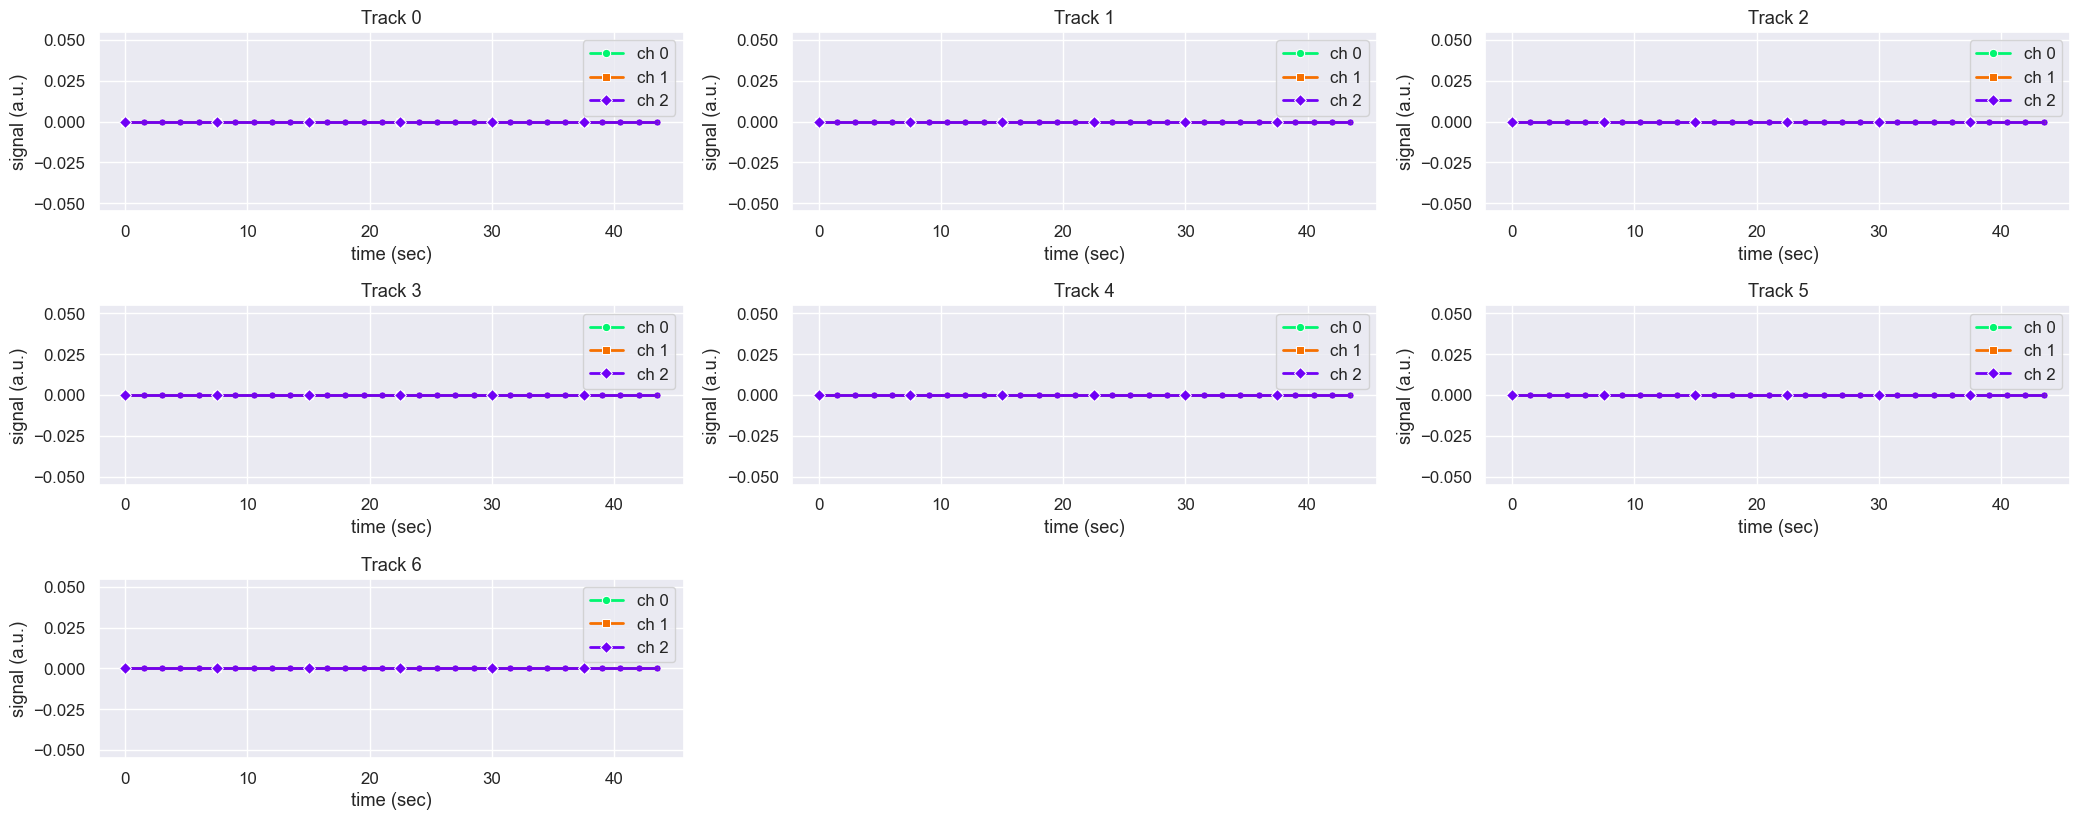

In [13]:
my_ta.isel(exp=0, fov=0).tplot.plot_track_signal_traces(track_ids=[0,1,2,3,4,5,6]);

In [ ]:
my_ta.isel(exp=0, fov=0).tplot.plot_tracks

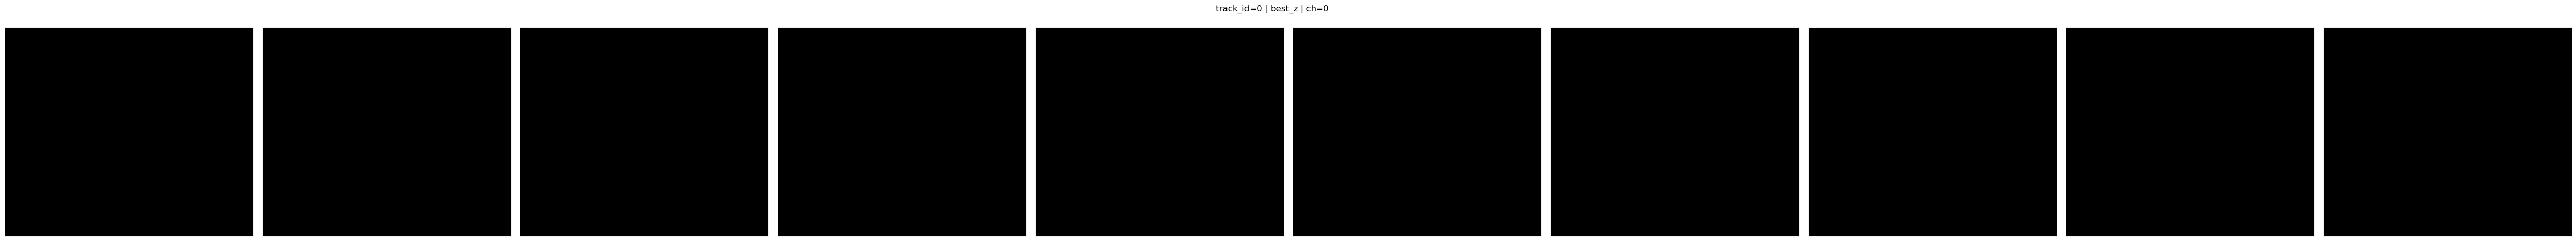

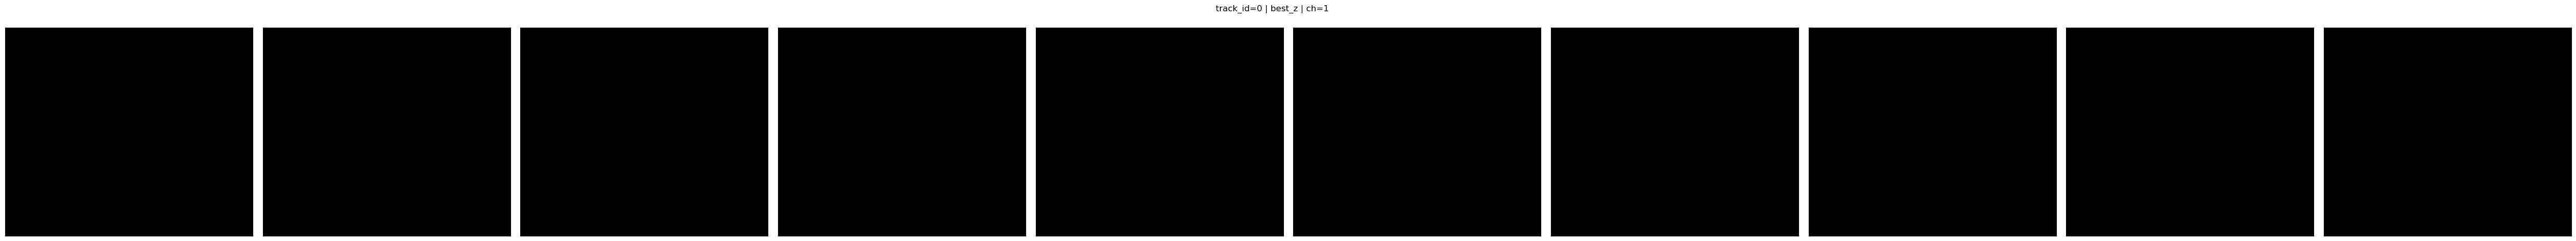

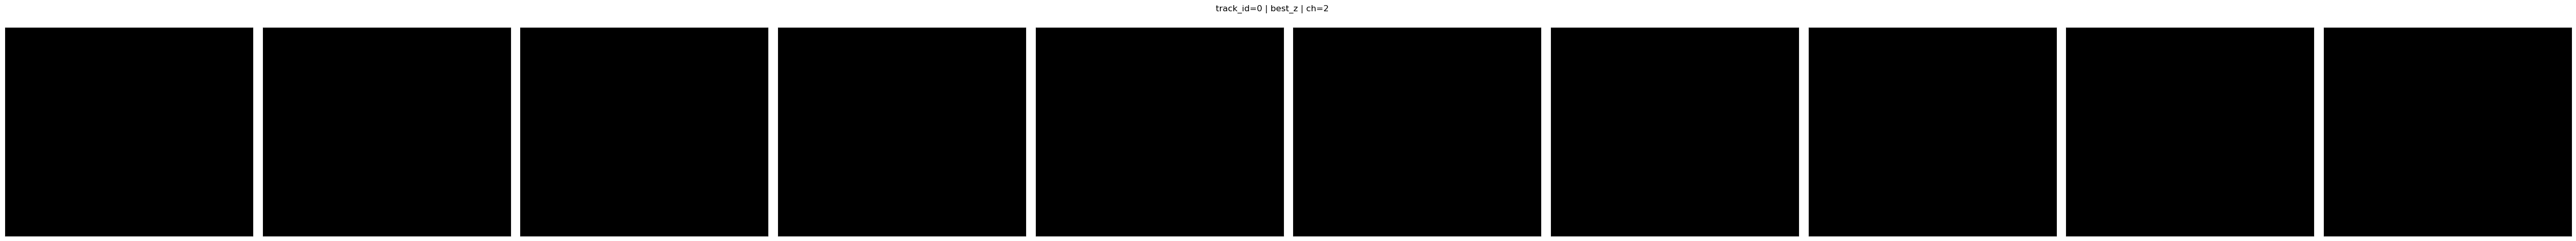

In [ ]:
# Check masks, if desired (without napari)
my_ta.isel(exp=0, fov=0).tplot.plot_trackarray_crops(track_ids=[0],t=(0,10,1),suppress_labels=True);
my_ta.isel(exp=0, fov=0).tplot.plot_trackarray_crops(track_ids=[0],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

In [ ]:
# Check masks with napari
viewer, layers = my_ta.napari.montage_viewer(
    row="track_id",
    col="t",
    show=("best_z", "ch0_mask"),
    ch=0,
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=[0.5,99.5],
    show_tile_text=False,  # adds layer w/ crop coords; takes memory,
)

KeyError: "Requested layer 'ch1_mask' not found in montage dataset."

In [18]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ta.measure.mask_props(source ="ch1_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

In [19]:
# =======================================
# SAVE YOUR WORK TO A NEW CROP/TRACKARRAY
# =======================================

my_file = ca.io.save_croparray(my_ta, output_dir=OUTPUT)
my_file

C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable xc with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
c:\Users\tstasevi\AppData\Local\anaconda3\envs\croparray_env\lib\site-packages\xarray\core\duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable yc with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\tstasevi\Documents\GitHub\croparray\croparray\io.py:467: SerializationWarning: saving variable zc with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)


WindowsPath('//129.82.125.64/tsnas2/galindo/1_Imaging_Data/XBP1/Cell01__49exp_fov.nc')

In [20]:
# check your saved data; note concatenation history is saved
temp = ca.tools.open_trackarray(my_file)
temp

TrackArray(tracks=182, t=10)

### Manual filtering of saved trackarray

In [1]:
import croparray as ca
from pathlib import Path
%gui qt

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/20260203/Cell_01_zstack__12exp_fov.nc')
INPUT_FILE = Path('/mnt/c/Users/tstasevi/Documents/Tim-Marianas/TrnlWithZNF598/20260210/Cell01__28exp_fov.nc')
INPUT_FILE = Path("//129.82.125.64/tsnas2/galindo/1_Imaging_Data/XBP1/Cell01__49exp_fov.nc") 

In [3]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import TrackArray
my_ta: TrackArray = ca.io.open_trackarray(INPUT_FILE, as_object=True)

In [5]:
# Quick and user-friendly manual filtering of tracks with napari 
# Create and save filter names (e.g. a 'bad' filter to remove noisy crops/tracks)
# Can also create filters like 'toi' to highlight tracks of interest  
filter_name = "bad"
viewer, layers, ft = my_ta.napari.manual_filter_montage(
    row="track_id",                 
    col="t",  # can be 'track_id' or 't'
    filter_name=filter_name,
    show=("best_z", "ch1_mask"),
    ch=1,
    colormaps={"ch1_mask":"magenta", "best_z":"green", filter_name:"yellow"},
    output_dir= INPUT_FILE.parent,
    show_tile_text=False, # adds layer w/ crop coords; takes memory,
    show_click_info=True, # useful for debugging
)

INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\tsnas2\galindo\1_Imaging_Data\XBP1\Cell01__49exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129

In [ ]:
# Test your filter:
my_ta.where(my_ta.ds[filter_name] == 0).napari.montage_viewer(row="track_id", col="t",show=("best_z","ch0_mask"),ch=0,show_tile_text=False)

(Viewer(camera=Camera(center=(0.0, np.float64(6982.0), np.float64(104.5)), zoom=np.float64(0.05442176870748299), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(0.0), np.float64(3.0), 0.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=4, ndisplay=2, order=(0, 1, 2, 3), axis_labels=('0', '1', '2', '3'), rollable=(True, True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(6.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(13964.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(209.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0), poi